In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
warnings.filterwarnings('ignore')

In [18]:
df = pd.read_csv('Cleaned_dataset.csv')
print(f"Shape     : {df.shape[0]:,} rows × {df.shape[1]} columns")
df.info()
df.sample(3)

Shape     : 16,754 rows × 18 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16754 entries, 0 to 16753
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     16754 non-null  int64  
 1   Price          16754 non-null  int64  
 2   Levy           16754 non-null  float64
 3   Manufacturer   16754 non-null  object 
 4   Model          16754 non-null  object 
 5   Prod. year     16754 non-null  int64  
 6   Category       16754 non-null  object 
 7   Fuel type      16754 non-null  object 
 8   Engine volume  16754 non-null  float64
 9   Mileage        16754 non-null  float64
 10  Cylinders      16754 non-null  float64
 11  Gear box type  16754 non-null  object 
 12  Drive wheels   16754 non-null  object 
 13  Doors          16754 non-null  float64
 14  Wheel          16754 non-null  object 
 15  Color          16754 non-null  object 
 16  Airbags        16754 non-null  int64  
 17  Leather_Bin  

,Unnamed: 0,Price,Levy,Manufacturer,Model,Prod. year,Category,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Leather_Bin
7501,8575,1333,777.0,NISSAN,Altima,2014,Sedan,Petrol,2.5,27656.0,4.0,Automatic,Front,4.0,Left wheel,Silver,12,1
3114,3583,1882,746.0,TOYOTA,Prius,2009,Sedan,Hybrid,1.5,142426.0,4.0,Automatic,Front,4.0,Left wheel,White,12,1
15257,17528,45210,770.0,HYUNDAI,Tucson,2016,Jeep,Diesel,1.7,60604.0,4.0,Automatic,Front,4.0,Left wheel,Black,4,1


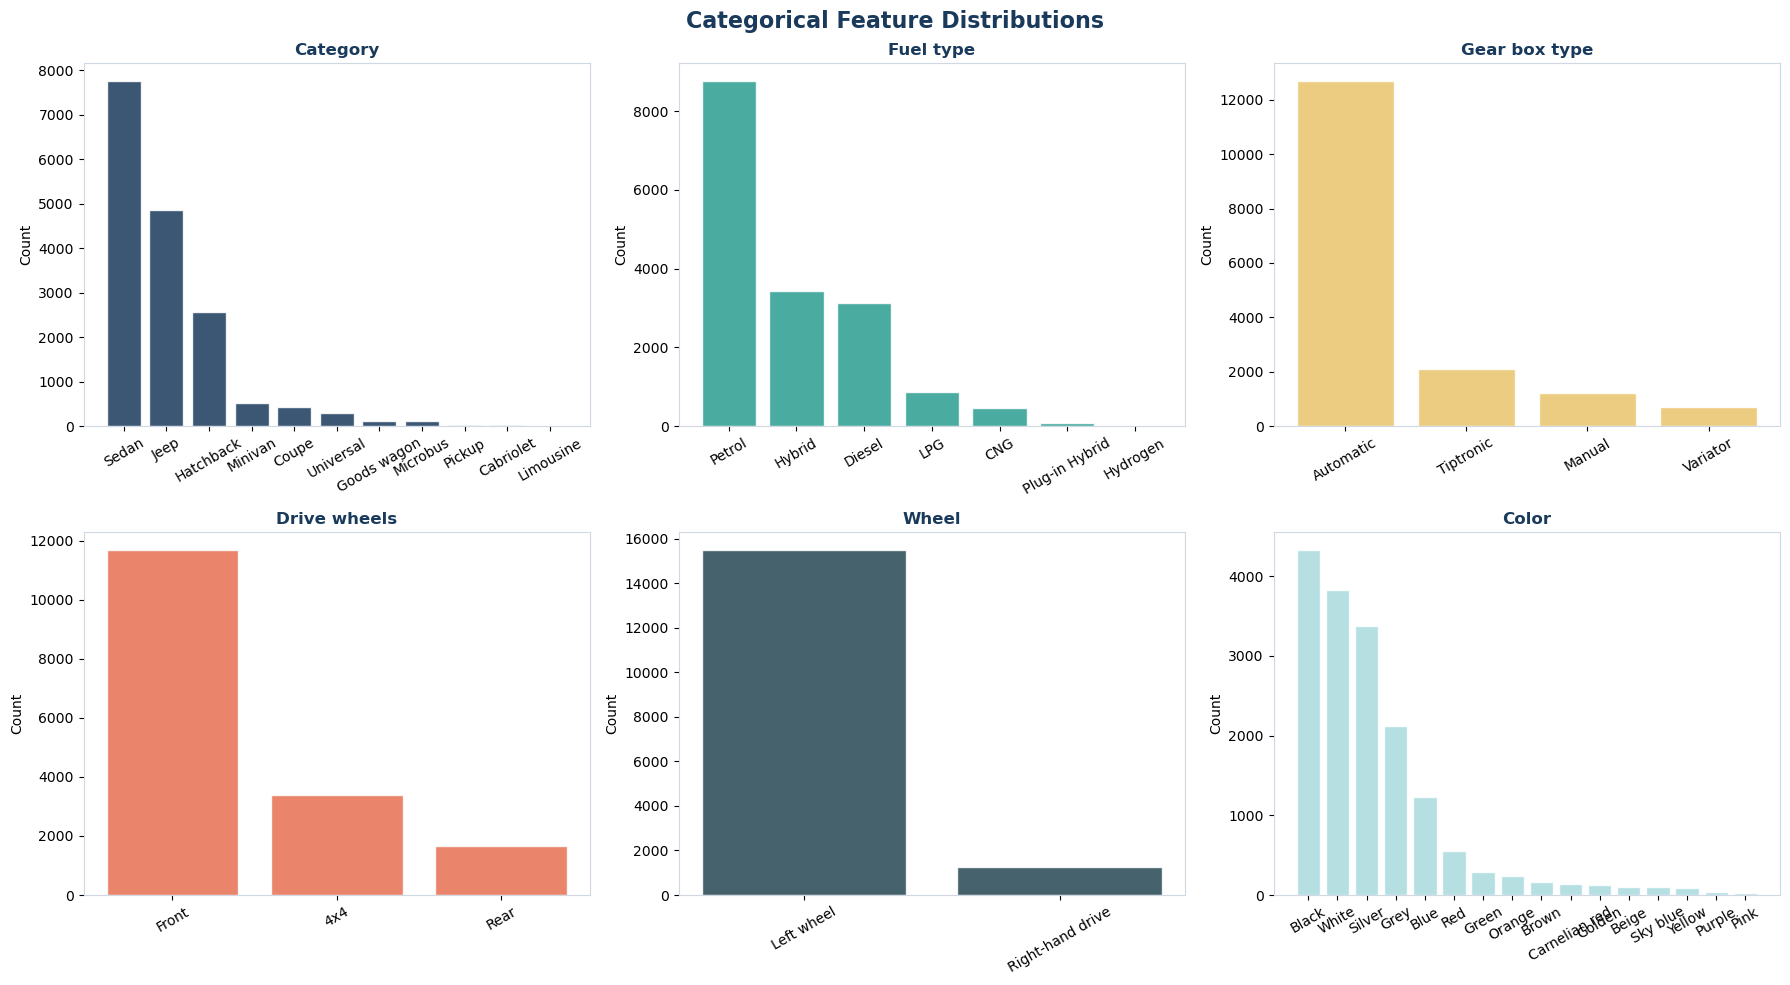

In [22]:
# Distribution of categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold', color='#1a3a5c')

cat_features = ['Category', 'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Color']
colors = ['#1a3a5c', '#2a9d8f', '#e9c46a', '#e76f51', '#264653', '#a8dadc']

for ax, feat, col in zip(axes.flatten(), cat_features, colors):
    counts = df[feat].value_counts()
    ax.bar(counts.index, counts.values, color=col, edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontsize=12, fontweight='bold', color='#1a3a5c')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('Count')
    for spine in ax.spines.values(): spine.set_color('#d0d8e4')

plt.tight_layout()
plt.savefig('Fig_1_Categorical_Feature_Distributions.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f4f8')
plt.show()

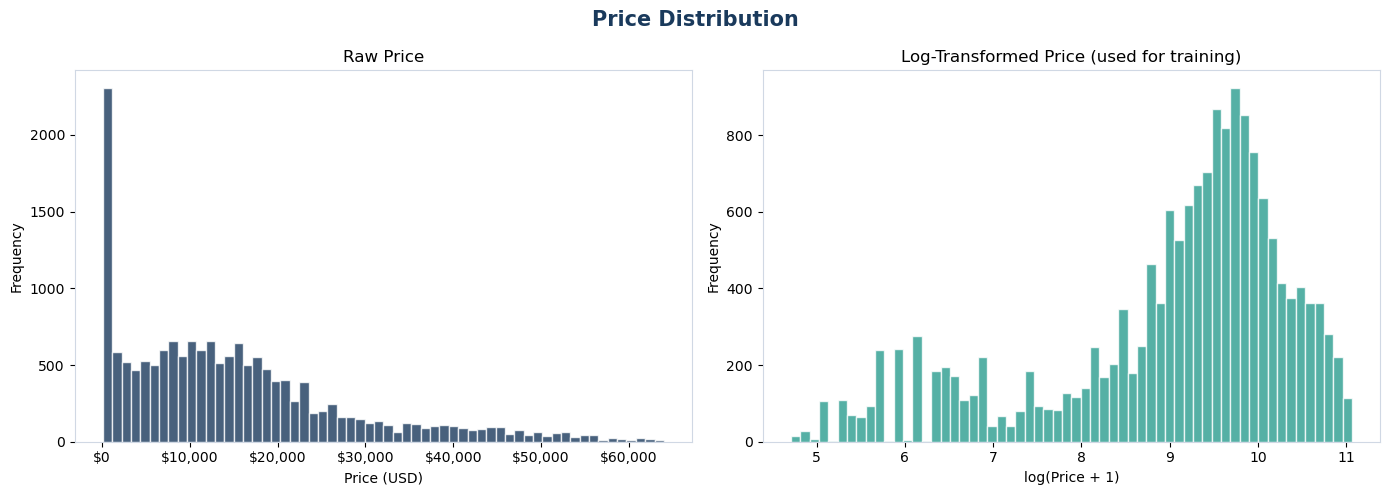

Price range: $110 → $63,976
Median price: $12,388


In [23]:
 #Price distribution (raw vs log-transformed)
df_plot = df.copy()
df_plot['Price'] = pd.to_numeric(df_plot['Price'], errors='coerce')
df_plot = df_plot[(df_plot['Price'] > 100) & (df_plot['Price'] < df_plot['Price'].quantile(0.99))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution', fontsize=15, fontweight='bold', color='#1a3a5c')

ax1.hist(df_plot['Price'], bins=60, color='#1a3a5c', alpha=0.8, edgecolor='white')
ax1.set_title('Raw Price', fontsize=12)
ax1.set_xlabel('Price (USD)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2.hist(np.log1p(df_plot['Price']), bins=60, color='#2a9d8f', alpha=0.8, edgecolor='white')
ax2.set_title('Log-Transformed Price (used for training)', fontsize=12)
ax2.set_xlabel('log(Price + 1)')

for ax in [ax1, ax2]:
    ax.set_ylabel('Frequency')
    for spine in ax.spines.values(): spine.set_color('#d0d8e4')

plt.tight_layout()
plt.savefig('Fig_2_Price_Distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f4f8')
plt.show()
print(f"Price range: ${df_plot['Price'].min():,.0f} → ${df_plot['Price'].max():,.0f}")
print(f"Median price: ${df_plot['Price'].median():,.0f}")

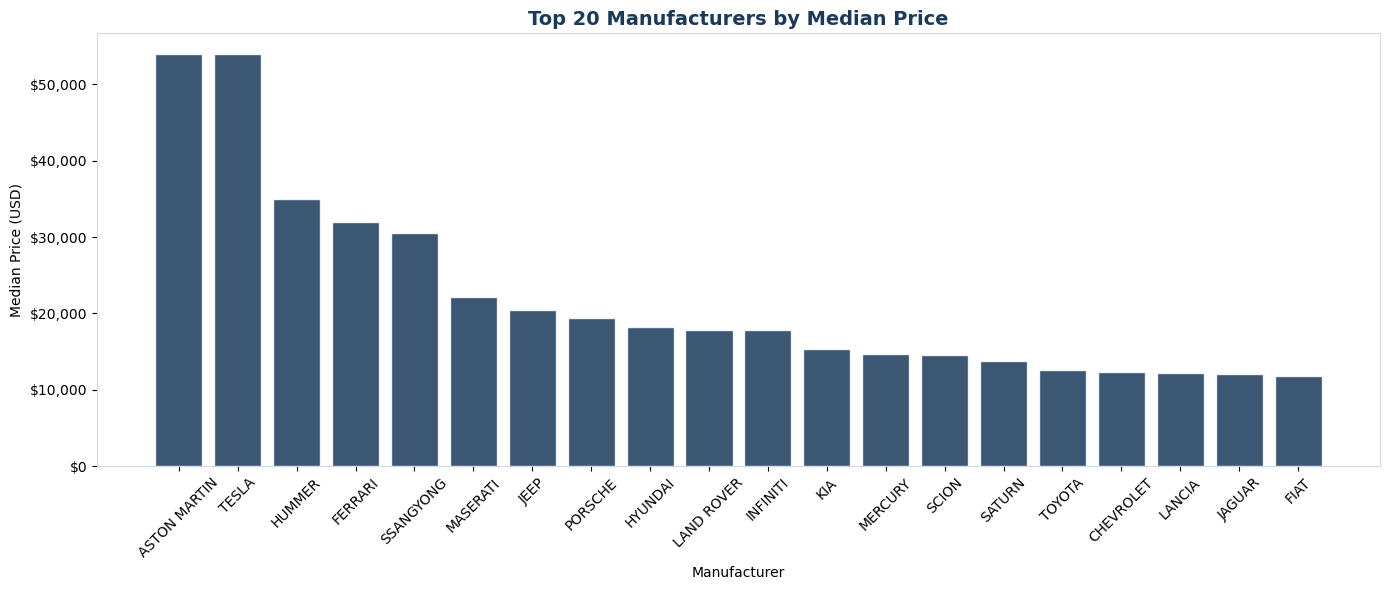

In [24]:
# Avg price by manufacturer (top 20)
df_plot['Manufacturer'] = df['Manufacturer']
top_brands = (df_plot.groupby('Manufacturer')['Price']
              .median().sort_values(ascending=False).head(20))

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(top_brands.index, top_brands.values, color='#1a3a5c', edgecolor='white', alpha=0.85)
ax.set_title('Top 20 Manufacturers by Median Price', fontsize=14, fontweight='bold', color='#1a3a5c')
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Median Price (USD)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for spine in ax.spines.values(): spine.set_color('#d0d8e4')
plt.tight_layout()
plt.savefig('Fig_3_Top 20 Manufacturers by Median Price.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f4f8')
plt.show()

In [9]:
# Car Age (proxy for depreciation)
df['Car_Age'] = 2024 - df['Prod. year']
df = df.drop(columns=['Prod. year'])

# Brand Value — mean price per manufacturer (market positioning signal)
brand_avg = df.groupby('Manufacturer')['Price'].mean()
df['Brand_Value'] = df['Manufacturer'].map(brand_avg)

# Mileage per Year — wear-and-tear normalised by age
df['Mileage_Per_Year'] = df['Mileage'] / (df['Car_Age'] + 1)

print("✅ Engineered features: Car_Age, Brand_Value, Mileage_Per_Year")
print()
df[['Car_Age', 'Brand_Value', 'Mileage_Per_Year']].describe().round(2)

✅ Engineered features: Car_Age, Brand_Value, Mileage_Per_Year



,Car_Age,Brand_Value,Mileage_Per_Year
count,16754.00,16754.00,1.675400e+04
mean,12.91,15638.81,6.264488e+04
std,5.61,5155.55,1.924189e+06
min,4.00,178.50,0.000000e+00
25%,9.00,12713.79,6.056520e+03
50%,12.00,14092.17,9.416670e+03
75%,14.00,22112.24,1.330864e+04
max,85.00,54000.00,1.263226e+08


In [28]:
cat_cols = ['Manufacturer', 'Model', 'Category', 'Fuel type',
            'Gear box type', 'Drive wheels', 'Wheel', 'Color']

le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

df = df.drop(columns=cat_cols)

print(f"✅ Encoded {len(cat_cols)} categorical columns")
print(f"Final feature set: {df.shape[1] - 1} features + 1 target")
print()
print("Columns:", list(df.columns))

✅ Encoded 8 categorical columns
Final feature set: 17 features + 1 target

Columns: ['Unnamed: 0', 'Price', 'Levy', 'Prod. year', 'Engine volume', 'Mileage', 'Cylinders', 'Doors', 'Airbags', 'Leather_Bin', 'Manufacturer_enc', 'Model_enc', 'Category_enc', 'Fuel type_enc', 'Gear box type_enc', 'Drive wheels_enc', 'Wheel_enc', 'Color_enc']


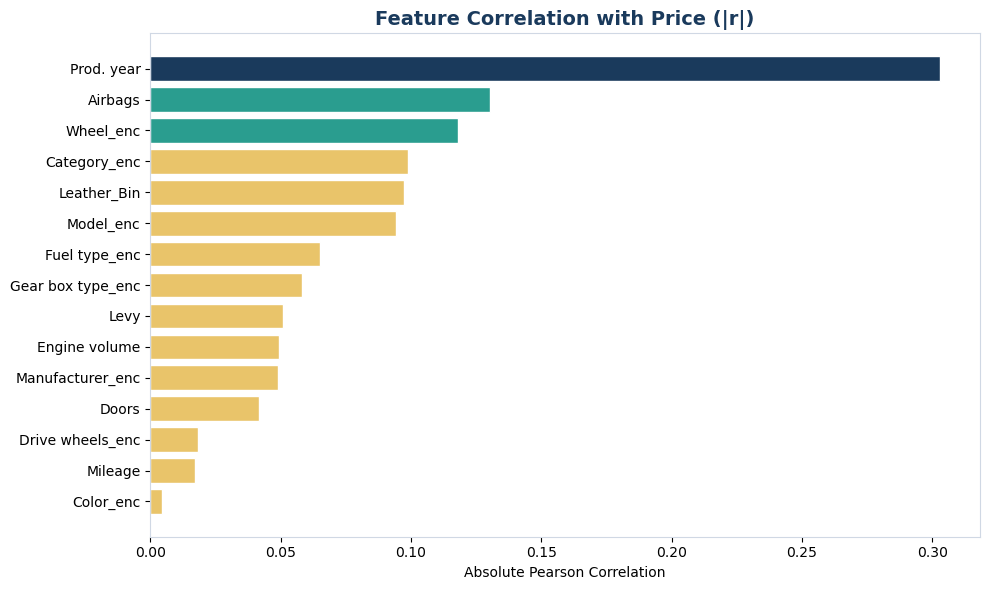

In [30]:
# Correlation with Price (top 15 features)
corr = df.corr()['Price'].drop('Price').abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#1a3a5c' if v > 0.3 else '#2a9d8f' if v > 0.1 else '#e9c46a' for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors_bar[::-1], edgecolor='white')
ax.set_title('Feature Correlation with Price (|r|)', fontsize=14, fontweight='bold', color='#1a3a5c')
ax.set_xlabel('Absolute Pearson Correlation')
for spine in ax.spines.values(): spine.set_color('#d0d8e4')
plt.tight_layout()
plt.savefig('Fig_4_Feature Correlation with Price.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f4f8')
plt.show()

In [31]:
df.to_csv("Cleaned_dataset1.csv")
print(f"✅ Data Exported Successfully")

✅ Data Exported Successfully
